# Globe Temperature Prediction Using 2 different Models

This notebook trains and evaluates Random Forest and Multiple Linear Regression models to predict globe temperature (Tg) from meteorological variables (T, RH, W, and SR). Model performance is evaluated using statistical metrics and cross-validation approaches. The predicted Tg values are also used to estimate WBGT conditions.

In [12]:
# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

# Machine learning models and validation
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Model evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Statistical analysis
import statsmodels.api as sm

# Visualization and regression analysis
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Folders
base = Path.cwd().parent     
data = base / "data"
results = base / "results"

### Read the files for 2025 and 2026:

In [13]:
ds_JFM_25 = pd.read_csv(data / "JFM_2025.csv")
ds_JAN_26 = pd.read_csv(data / "JAN_2026.csv")

ds_JFM_25.tail(3)

,time,Tg,T,RH,W,SR
4817,2025-03-31 15:50:00,28.22,26.7,73,1.8,130
4818,2025-03-31 15:55:00,28.38,26.4,74,1.8,140
4819,2025-03-31 16:00:00,28.50,26.3,74,1.8,135


In [14]:
ds_JAN_26.tail(3)

,time,Tg,T,RH,W,SR
421,2026-01-26 14:40:00,40.02,29.62,50.60,3.142,738.3911
422,2026-01-26 14:45:00,39.68,29.69,50.07,2.408,702.8136
423,2026-01-26 14:50:00,39.30,29.69,50.01,2.482,717.3292


### Train the RANDOM FOREST (RF) model with the 2025 data

In [3]:
# Random Forest with direct train-test split (no k-fold cross-validation)


# Predictor variables (meteorological inputs)
X_rf = ds_JFM_25[['T', 'RH', 'W', 'SR']]

# Target variable (globe temperature)
y_rf = ds_JFM_25['Tg']

# Train–test split (80% training, 20% testing)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=90
)

# Random Forest regressor
rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=90,
    n_jobs=-1
)

# Model fitting
rf_model.fit(X_train_rf, y_train_rf)

# Prediction on the test set
y_pred_rf = rf_model.predict(X_test_rf)

# Performance metrics
r2_rf = r2_score(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)

print(f"R²   = {r2_rf:.3f}")
print(f"RMSE = {rmse_rf:.3f} °C")
print(f"MAE  = {mae_rf:.3f} °C")

R²   = 0.895
RMSE = 1.019 °C
MAE  = 0.776 °C


In [4]:
# Save the RF model in a .pkl

joblib.dump(rf_model, results /'RF_JFM_2025.pkl')
modelo = joblib.load(results /'RF_JFM_2025.pkl')
modelo.feature_names_in_

array(['T', 'RH', 'W', 'SR'], dtype=object)

In [24]:
# Random Forest with 5-fold cross-validation


# 5-fold cross-validation setup
kf_rf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=90
)

# Predictor and target variables for K-fold RF
X_kf_rf = ds_JFM_25[['T', 'RH', 'W', 'SR']]
y_kf_rf = ds_JFM_25['Tg']

# Storage for cross-validation metrics
r2_kf_rf = []
rmse_kf_rf = []
mae_kf_rf = []

# K-fold training and evaluation
for train_idx_kf_rf, test_idx_kf_rf in kf_rf.split(X_kf_rf):

    X_train_kf_rf = X_kf_rf.iloc[train_idx_kf_rf]
    X_test_kf_rf = X_kf_rf.iloc[test_idx_kf_rf]
    y_train_kf_rf = y_kf_rf.iloc[train_idx_kf_rf]
    y_test_kf_rf = y_kf_rf.iloc[test_idx_kf_rf]

    # Random Forest model
    rf_kf_model = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=90,
        n_jobs=-1
    )

    # Model fitting
    rf_kf_model.fit(X_train_kf_rf, y_train_kf_rf)

    # Prediction
    y_pred_kf_rf = rf_kf_model.predict(X_test_kf_rf)

    # Performance metrics
    r2_kf_rf.append(r2_score(y_test_kf_rf, y_pred_kf_rf))
    rmse_kf_rf.append(np.sqrt(mean_squared_error(y_test_kf_rf, y_pred_kf_rf)))
    mae_kf_rf.append(mean_absolute_error(y_test_kf_rf, y_pred_kf_rf))

# Mean and standard deviation across folds
print(f"R²   = {np.mean(r2_kf_rf):.3f}, std = {np.std(r2_kf_rf):.3f}")
print(f"RMSE = {np.mean(rmse_kf_rf):.3f}, std = {np.std(rmse_kf_rf):.3f} °C")
print(f"MAE  = {np.mean(mae_kf_rf):.3f}, std = {np.std(mae_kf_rf):.3f} °C")

R²   = 0.881, std = 0.010
RMSE = 1.072, std = 0.028 °C
MAE  = 0.821, std = 0.024 °C


In [37]:
# Compare the estimated vs real WBGT


# Wet-bulb temperature estimation (Stull, 2011)

T_test_rf = X_test_rf['T']
RH_test_rf = X_test_rf['RH']

Tw_test_rf = (
    T_test_rf * np.arctan(0.151977 * np.sqrt(RH_test_rf + 8.313659))
    + np.arctan(T_test_rf + RH_test_rf)
    - np.arctan(RH_test_rf - 1.676331)
    + 0.00391838 * RH_test_rf**1.5 * np.arctan(0.023101 * RH_test_rf)
    - 4.686035
)

# WBGT observed (using measured globe temperature)
WBGT_obs_rf = 0.7 * Tw_test_rf + 0.2 * y_test_rf + 0.1 * T_test_rf

# WBGT estimated (using predicted globe temperature)
WBGT_pred_rf = 0.7 * Tw_test_rf + 0.2 * y_pred_rf + 0.1 * T_test_rf

# WBGT performance metrics
r2_wbgt_rf = r2_score(WBGT_obs_rf, WBGT_pred_rf)
rmse_wbgt_rf = np.sqrt(mean_squared_error(WBGT_obs_rf, WBGT_pred_rf))
mae_wbgt_rf = mean_absolute_error(WBGT_obs_rf, WBGT_pred_rf)

print(f"WBGT R²   = {r2_wbgt_rf:.3f}")
print(f"WBGT RMSE = {rmse_wbgt_rf:.3f} °C")
print(f"WBGT MAE  = {mae_wbgt_rf:.3f} °C")

WBGT R²   = 0.974
WBGT RMSE = 0.204 °C
WBGT MAE  = 0.155 °C


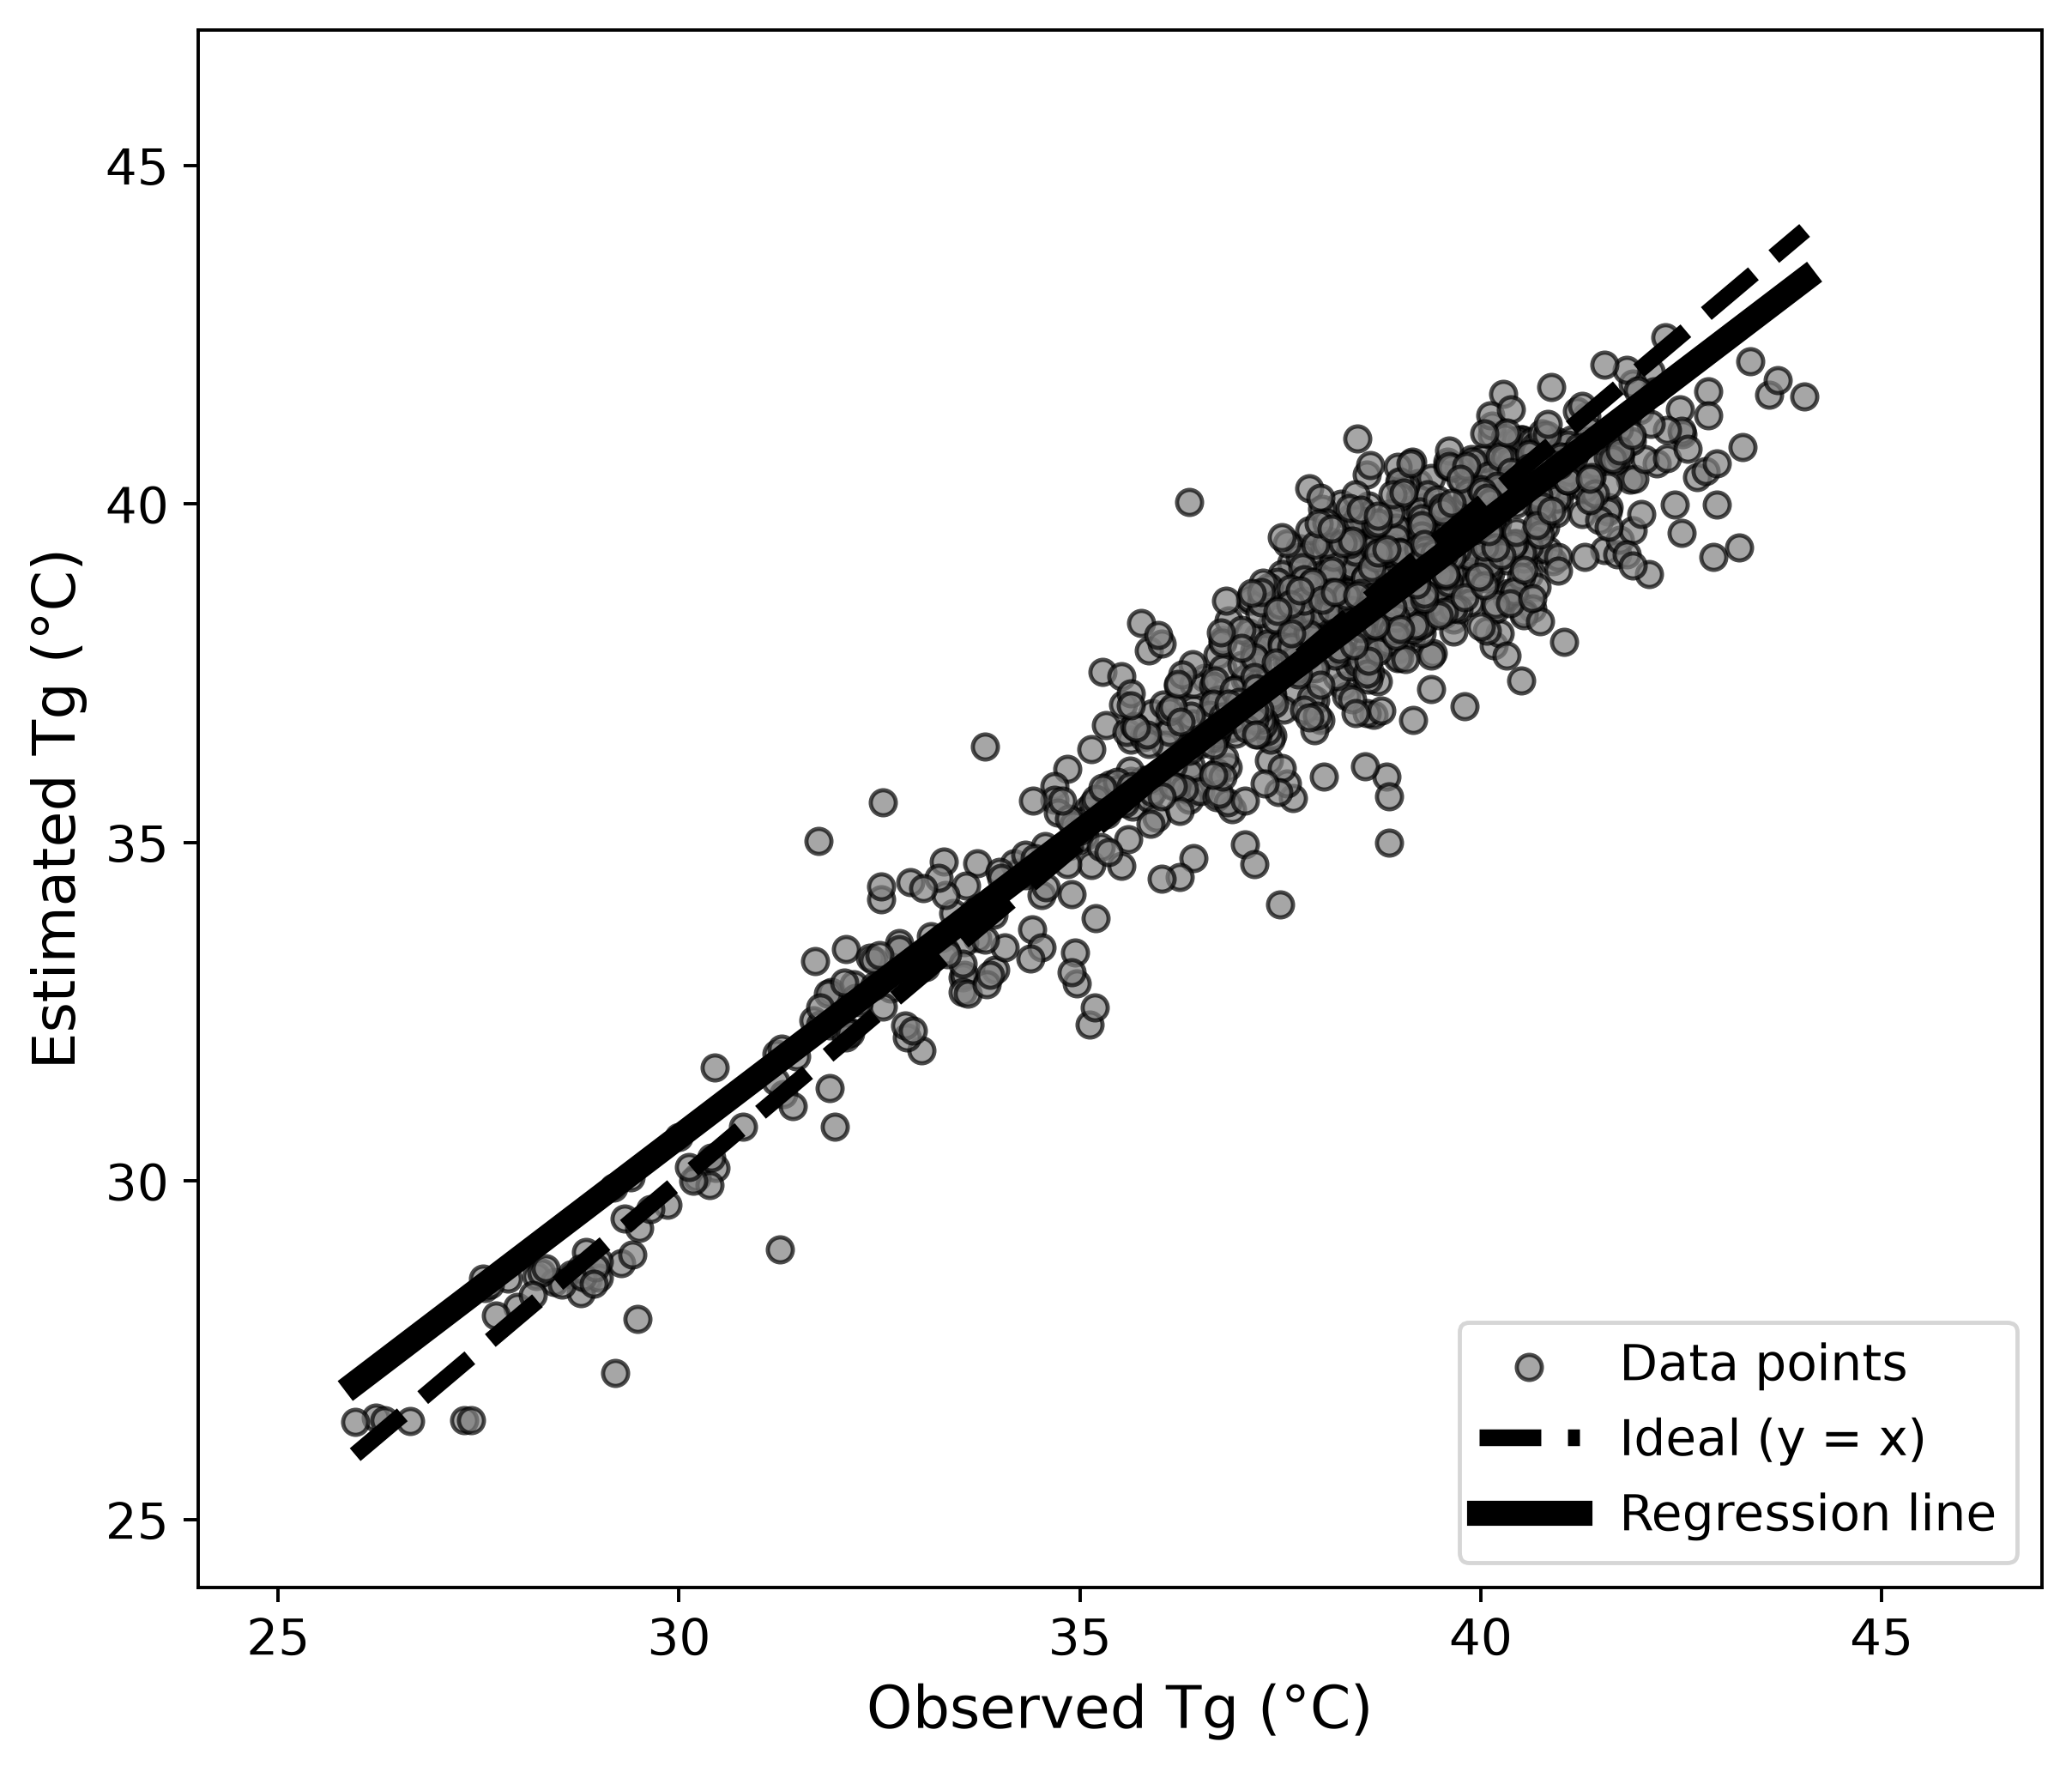

In [43]:
# Plot the regression line


# Regression line
slope_rf, intercept_rf, _, _, _ = linregress(y_test_rf, y_pred_rf)

# Observed vs predicted plot
plt.figure(figsize=(7, 6), dpi=350)

# Data points
plt.scatter(
    y_test_rf,
    y_pred_rf,
    alpha=0.7,
    color='gray',
    edgecolor='k',
    label="Data points"
)

# Ideal line (y = x)
plt.plot(
    [y_test_rf.min(), y_test_rf.max()],
    [y_test_rf.min(), y_test_rf.max()],
    color='black',
    linestyle='--',
    label='Ideal (y = x)',
    linewidth=4
)

# Regression line
x_vals_rf = np.array([y_test_rf.min(), y_test_rf.max()])
y_vals_rf = intercept_rf + slope_rf * x_vals_rf

plt.plot(
    x_vals_rf,
    y_vals_rf,
    'k-',
    linewidth=6,
    label='Regression line'
)

# Labels
plt.xlabel("Observed Tg (°C)", fontsize=14)
plt.ylabel("Estimated Tg (°C)", fontsize=14)
plt.xlim(24, 47)
plt.ylim(24, 47)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()

plt.savefig(
    results / "RF_plot.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

### Analysis with the 2026 data for RF

In [ ]:
# External validation of RF model using JAN 2026 data


# Load trained Random Forest model (JFM 2025)
rf_model_2026 = joblib.load(
    results / "RF_JFM_2025.pkl"
)

# Predictor variables required by the model
X_rf_2026 = ds_JAN_26[['T', 'RH', 'W', 'SR']].astype(float)

# Remove missing values
X_rf_2026 = X_rf_2026.dropna()


# Predict globe temperature
ds_JAN_26.loc[X_rf_2026.index, 'Tg_rf'] = rf_model_2026.predict(
    X_rf_2026
)


# Evaluation metrics
r2_rf_2026 = r2_score(
    ds_JAN_26.loc[X_rf_2026.index, 'Tg'],
    ds_JAN_26.loc[X_rf_2026.index, 'Tg_rf']
)

mae_rf_2026 = mean_absolute_error(
    ds_JAN_26.loc[X_rf_2026.index, 'Tg'],
    ds_JAN_26.loc[X_rf_2026.index, 'Tg_rf']
)

rmse_rf_2026 = np.sqrt(
    mean_squared_error(
        ds_JAN_26.loc[X_rf_2026.index, 'Tg'],
        ds_JAN_26.loc[X_rf_2026.index, 'Tg_rf']
    )
)


print(f"R²   = {r2_rf_2026:.3f}")
print(f"MAE  = {mae_rf_2026:.3f} °C")
print(f"RMSE = {rmse_rf_2026:.3f} °C")

R²   = 0.889
MAE  = 0.905 °C
RMSE = 1.230 °C


### Train the MULTIPLE LINEAR REGRESSION (MLR) model with the 2025 data

In [22]:
# Multiple Linear Regression with direct train-test split (no k-fold cross-validation)


# Predictor variables (meteorological inputs)
X_mlr = ds_JFM_25[['T', 'RH', 'W', 'SR']]

# Target variable (globe temperature)
y_mlr = ds_JFM_25['Tg']

# Train–test split (80% training, 20% testing)
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr,
    y_mlr,
    test_size=0.20,
    random_state=90
)

# Multiple Linear Regression model
mlr_model = LinearRegression()

# Model fitting
mlr_model.fit(X_train_mlr, y_train_mlr)

# Prediction on the test set
y_pred_mlr = mlr_model.predict(X_test_mlr)

# Performance metrics
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test_mlr, y_pred_mlr))
mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)

print(f"R²   = {r2_mlr:.3f}")
print(f"RMSE = {rmse_mlr:.3f} °C")
print(f"MAE  = {mae_mlr:.3f} °C")

# Model equation
print("\nMODEL EQUATION:")
print(
    f"Tg = {mlr_model.intercept_:.6f} + "
    f"{mlr_model.coef_[0]:.6f}×T + "
    f"{mlr_model.coef_[1]:.6f}×RH + "
    f"{mlr_model.coef_[2]:.6f}×W + "
    f"{mlr_model.coef_[3]:.6f}×SR"
)

R²   = 0.793
RMSE = 1.430 °C
MAE  = 1.126 °C

MODEL EQUATION:
Tg = 10.661409 + 0.822573×T + -0.014319×RH + -1.065556×W + 0.010735×SR


In [26]:
# Multiple Linear Regression with 5-fold cross-validation


# 5-fold cross-validation setup
kf_mlr = KFold(
    n_splits=5,
    shuffle=True,
    random_state=90
)

# Predictor and target variables for K-fold MLR
X_kf_mlr = ds_JFM_25[['T', 'RH', 'W', 'SR']]
y_kf_mlr = ds_JFM_25['Tg']

# Storage for cross-validation metrics and coefficients
r2_kf_mlr = []
rmse_kf_mlr = []
mae_kf_mlr = []

coef_kf_mlr = []
intercept_kf_mlr = []

# K-fold training and evaluation
for train_idx_kf_mlr, test_idx_kf_mlr in kf_mlr.split(X_kf_mlr):

    X_train_kf_mlr = X_kf_mlr.iloc[train_idx_kf_mlr]
    X_test_kf_mlr = X_kf_mlr.iloc[test_idx_kf_mlr]
    y_train_kf_mlr = y_kf_mlr.iloc[train_idx_kf_mlr]
    y_test_kf_mlr = y_kf_mlr.iloc[test_idx_kf_mlr]

    # Multiple Linear Regression model
    mlr_kf_model = LinearRegression()

    # Model fitting
    mlr_kf_model.fit(X_train_kf_mlr, y_train_kf_mlr)

    # Prediction
    y_pred_kf_mlr = mlr_kf_model.predict(X_test_kf_mlr)

    # Performance metrics
    r2_kf_mlr.append(r2_score(y_test_kf_mlr, y_pred_kf_mlr))
    rmse_kf_mlr.append(np.sqrt(mean_squared_error(y_test_kf_mlr, y_pred_kf_mlr)))
    mae_kf_mlr.append(mean_absolute_error(y_test_kf_mlr, y_pred_kf_mlr))

    # Model coefficients
    coef_kf_mlr.append(mlr_kf_model.coef_)
    intercept_kf_mlr.append(mlr_kf_model.intercept_)


# Mean and standard deviation across folds
print(f"R²   = {np.mean(r2_kf_mlr):.3f}, std = {np.std(r2_kf_mlr):.3f}")
print(f"RMSE = {np.mean(rmse_kf_mlr):.3f}, std = {np.std(rmse_kf_mlr):.3f} °C")
print(f"MAE  = {np.mean(mae_kf_mlr):.3f}, std = {np.std(mae_kf_mlr):.3f} °C")


# Average model equation across folds
coef_mean_kf_mlr = np.mean(coef_kf_mlr, axis=0)
coef_std_kf_mlr = np.std(coef_kf_mlr, axis=0)

intercept_mean_kf_mlr = np.mean(intercept_kf_mlr)
intercept_std_kf_mlr = np.std(intercept_kf_mlr)

print("\nMODEL EQUATION (average across folds):")
print(f"Tg = {intercept_mean_kf_mlr:.5f}, std = {intercept_std_kf_mlr:.5f}")

for var, coef, std in zip(
    ['T', 'RH', 'W', 'SR'],
    coef_mean_kf_mlr,
    coef_std_kf_mlr
):
    print(f"    + {coef:.5f}, std = {std:.5f} × {var}")

R²   = 0.792, std = 0.010
RMSE = 1.419, std = 0.012 °C
MAE  = 1.120, std = 0.008 °C

MODEL EQUATION (average across folds):
Tg = 11.76964, std = 0.59858
    + 0.79925, std = 0.01414 × T
    + -0.02045, std = 0.00343 × RH
    + -1.08603, std = 0.01467 × W
    + 0.01081, std = 0.00008 × SR


In [38]:
# Compare the estimated vs real WBGT


# Wet-bulb temperature estimation (Stull, 2011)
T_test_mlr = X_test_mlr['T']
RH_test_mlr = X_test_mlr['RH']

Tw_test_mlr = (
    T_test_mlr * np.arctan(0.151977 * np.sqrt(RH_test_mlr + 8.313659))
    + np.arctan(T_test_mlr + RH_test_mlr)
    - np.arctan(RH_test_mlr - 1.676331)
    + 0.00391838 * RH_test_mlr**1.5 * np.arctan(0.023101 * RH_test_mlr)
    - 4.686035
)

# WBGT observed (using measured globe temperature)
WBGT_obs_mlr = 0.7 * Tw_test_mlr + 0.2 * y_test_mlr + 0.1 * T_test_mlr

# WBGT estimated (using MLR predicted globe temperature)
WBGT_pred_mlr = 0.7 * Tw_test_mlr + 0.2 * y_pred_mlr + 0.1 * T_test_mlr

# WBGT performance metrics
r2_wbgt_mlr = r2_score(WBGT_obs_mlr, WBGT_pred_mlr)
rmse_wbgt_mlr = np.sqrt(mean_squared_error(WBGT_obs_mlr, WBGT_pred_mlr))
mae_wbgt_mlr = mean_absolute_error(WBGT_obs_mlr, WBGT_pred_mlr)

print(f"WBGT R²   = {r2_wbgt_mlr:.3f}")
print(f"WBGT RMSE = {rmse_wbgt_mlr:.3f} °C")
print(f"WBGT MAE  = {mae_wbgt_mlr:.3f} °C")

WBGT R²   = 0.948
WBGT RMSE = 0.286 °C
WBGT MAE  = 0.225 °C


In [31]:
# Ordinary Least Squares (OLS) model for statistical significance assessment
# This analysis is only used to evaluate coefficient significance (p-values)
# and does not generate predictions for model evaluation.

import statsmodels.api as sm

# Predictor variables and target variable for significance analysis
X_sigcheck = ds_JFM_25[['T', 'RH', 'W', 'SR']].astype(float)
X_sigcheck = sm.add_constant(X_sigcheck)

y_sigcheck = ds_JFM_25['Tg'].astype(float)

# Fit OLS model
ols_sigcheck_model = sm.OLS(
    y_sigcheck,
    X_sigcheck
).fit()

# Display statistical summary (coefficients, p-values, confidence intervals)
print(ols_sigcheck_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     Tg   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     4619.
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        10:16:56   Log-Likelihood:                -8522.1
No. Observations:                4820   AIC:                         1.705e+04
Df Residuals:                    4815   BIC:                         1.709e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.7581      1.005     11.703      0.0

In [36]:
# Variance Inflation Factor (VIF) analysis
# Used to assess multicollinearity among predictor variables.

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Predictor variables for VIF assessment
X_vif_sigcheck = ds_JFM_25[['T', 'RH', 'W', 'SR']].astype(float)

# Add intercept term
X_vif_sigcheck = sm.add_constant(X_vif_sigcheck)

# Calculate VIF values
vif_sigcheck_df = pd.DataFrame()
vif_sigcheck_df["Variable"] = X_vif_sigcheck.columns
vif_sigcheck_df["VIF"] = [
    variance_inflation_factor(X_vif_sigcheck.values, i)
    for i in range(X_vif_sigcheck.shape[1])
]

print(vif_sigcheck_df)

  Variable          VIF
0    const  2417.774510
1        T     3.104604
2       RH     3.263335
3        W     1.515285
4       SR     1.368224


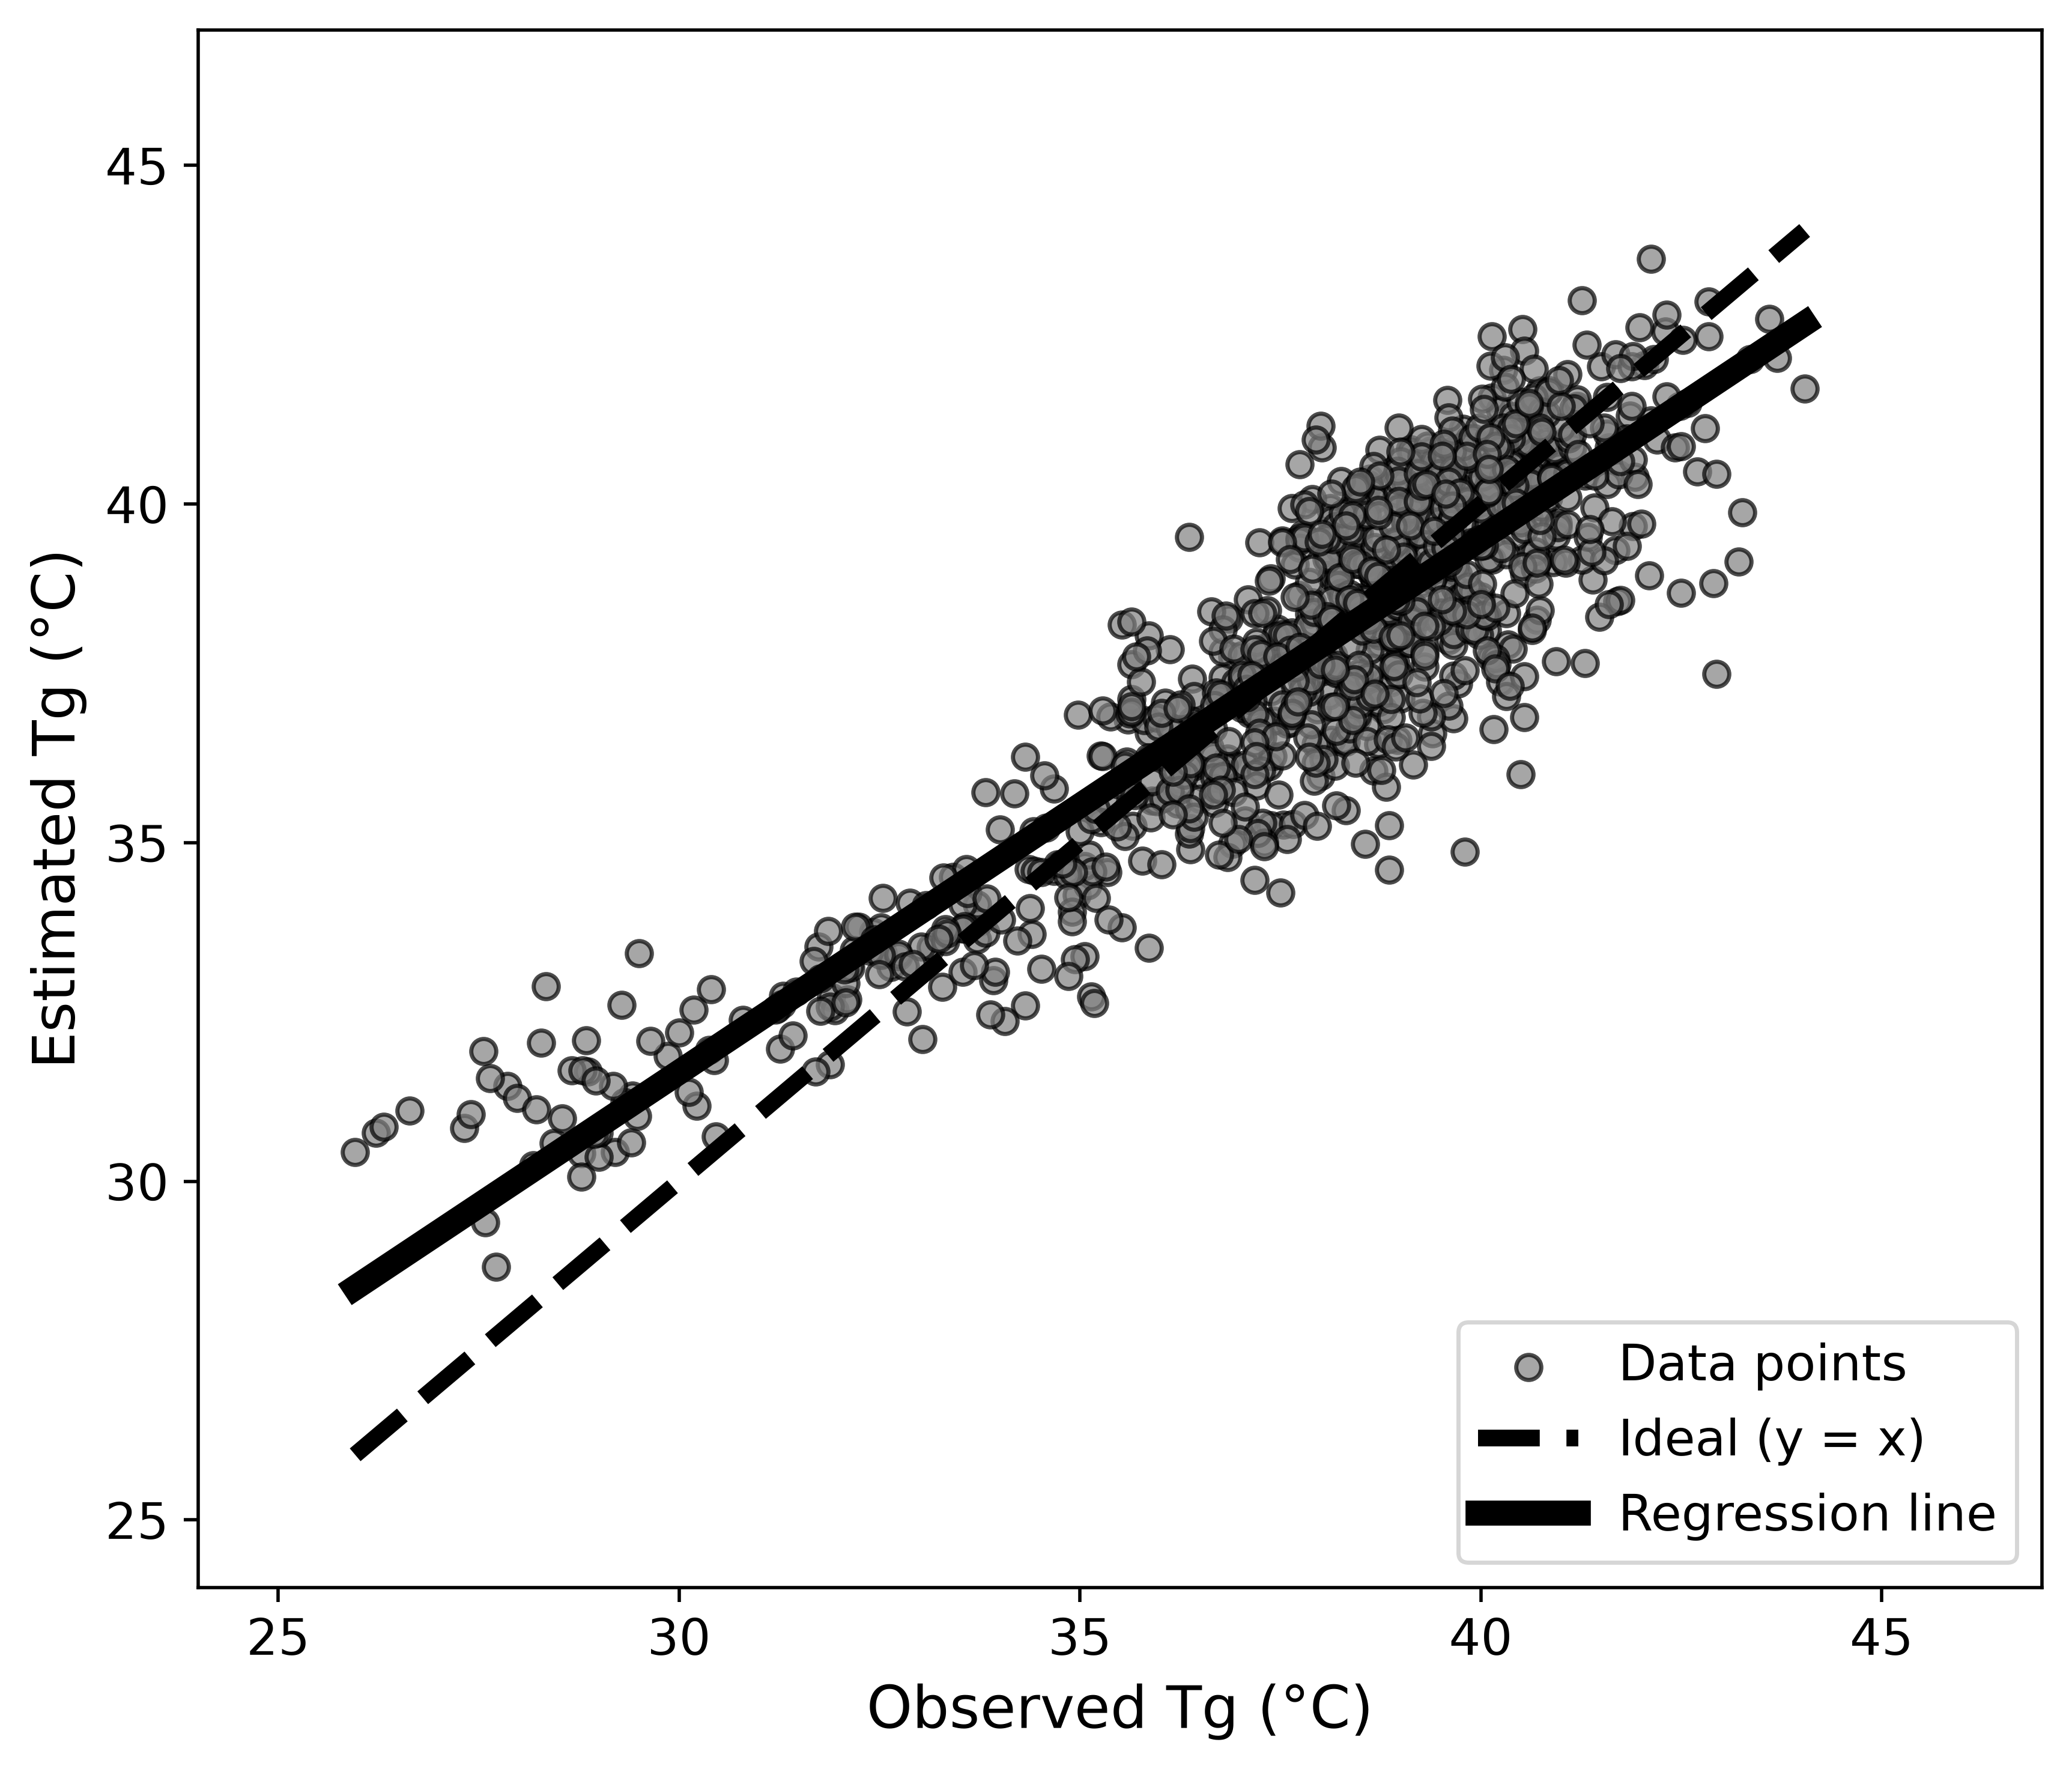

In [41]:
# Plot the regression line


# Regression line
slope_mlr, intercept_mlr, _, _, _ = linregress(y_test_mlr, y_pred_mlr)

# Observed vs predicted plot
plt.figure(figsize=(7, 6), dpi=500)

# Data points
plt.scatter(
    y_test_mlr,
    y_pred_mlr,
    alpha=0.7,
    color='gray',
    edgecolor='k',
    label="Data points"
)

# Ideal line (y = x)
plt.plot(
    [y_test_mlr.min(), y_test_mlr.max()],
    [y_test_mlr.min(), y_test_mlr.max()],
    color='black',
    linestyle='--',
    label='Ideal (y = x)',
    linewidth=4
)

# Regression line
x_vals_mlr = np.array([y_test_mlr.min(), y_test_mlr.max()])
y_vals_mlr = intercept_mlr + slope_mlr * x_vals_mlr

plt.plot(
    x_vals_mlr,
    y_vals_mlr,
    'k-',
    linewidth=6,
    label='Regression line'
)

# Labels
plt.xlabel("Observed Tg (°C)", fontsize=14)
plt.ylabel("Estimated Tg (°C)", fontsize=14)
plt.xlim(24, 47)
plt.ylim(24, 47)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()

# Save figure
plt.savefig(
    results / "MLR_plot.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

### Analysis with the 2026 data for MLR

In [ ]:
# External validation of MLR model using JAN 2026 data

# MLR model equation obtained from JFM 2025 training
def calc_Tg_mlr_2026(T, RH, W, SR):
    return (
        10.661409
        + 0.822573 * T
        - 0.014319 * RH
        - 1.065556 * W
        + 0.010735 * SR
    )


# Estimate Tg using MLR model
ds_JAN_26['Tg_mlr'] = calc_Tg_mlr_2026(
    ds_JAN_26['T'],
    ds_JAN_26['RH'],
    ds_JAN_26['W'],
    ds_JAN_26['SR']
)


# Evaluation metrics
mask_mlr_2026 = ds_JAN_26[['Tg', 'Tg_mlr']].notna().all(axis=1)

r2_mlr_2026 = r2_score(
    ds_JAN_26.loc[mask_mlr_2026, 'Tg'],
    ds_JAN_26.loc[mask_mlr_2026, 'Tg_mlr']
)

mae_mlr_2026 = mean_absolute_error(
    ds_JAN_26.loc[mask_mlr_2026, 'Tg'],
    ds_JAN_26.loc[mask_mlr_2026, 'Tg_mlr']
)

rmse_mlr_2026 = np.sqrt(
    mean_squared_error(
        ds_JAN_26.loc[mask_mlr_2026, 'Tg'],
        ds_JAN_26.loc[mask_mlr_2026, 'Tg_mlr']
    )
)


print(f"R²   = {r2_mlr_2026:.3f}")
print(f"MAE  = {mae_mlr_2026:.3f} °C")
print(f"RMSE = {rmse_mlr_2026:.3f} °C")

R²   = 0.790
MAE  = 1.388 °C
RMSE = 1.693 °C
